# Biodiversity Project: Endangered Species in Different Parks 
Data Source: National Parks Service

## Import Libraries and Adjust Output Parameters

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', None)  # No limit on the number of columns
pd.set_option('display.width', 1000)        # Set a larger display width for horizontal output
pd.set_option('display.max_colwidth', None) # Avoid truncation of column content

## Load Data

In [2]:
si_df = pd.read_csv('species_info.csv')
obs_df = pd.read_csv('observations.csv')

print('Species Info:')
print(si_df.head(), '\n\n')

print('Observations:')
print(obs_df.head())

Species Info:
  category                scientific_name                                                    common_names conservation_status
0   Mammal  Clethrionomys gapperi gapperi                                        Gapper's Red-Backed Vole                 NaN
1   Mammal                      Bos bison                                           American Bison, Bison                 NaN
2   Mammal                     Bos taurus  Aurochs, Aurochs, Domestic Cattle (Feral), Domesticated Cattle                 NaN
3   Mammal                     Ovis aries               Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)                 NaN
4   Mammal                 Cervus elaphus                                                   Wapiti Or Elk                 NaN 


Observations:
            scientific_name                            park_name  observations
0        Vicia benghalensis  Great Smoky Mountains National Park            68
1            Neovison vison  Great Smoky Mountains Nati

## Clean Data

In [3]:
# cleaning si_df.conservation_status to fill NaN with No Intervention to better represent the population in plotting this column.
si_df.conservation_status = si_df.conservation_status.fillna('No Intervention')
print(si_df.head())

  category                scientific_name                                                    common_names conservation_status
0   Mammal  Clethrionomys gapperi gapperi                                        Gapper's Red-Backed Vole     No Intervention
1   Mammal                      Bos bison                                           American Bison, Bison     No Intervention
2   Mammal                     Bos taurus  Aurochs, Aurochs, Domestic Cattle (Feral), Domesticated Cattle     No Intervention
3   Mammal                     Ovis aries               Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)     No Intervention
4   Mammal                 Cervus elaphus                                                   Wapiti Or Elk     No Intervention


## Explore species_info.csv

In [4]:
print('Species Info')
print(si_df.describe(), '\n')

print(f'Rows: {si_df.shape[0]} \nColumns: {si_df.shape[1]}')


Species Info
              category    scientific_name        common_names conservation_status
count             5824               5824                5824                5824
unique               7               5541                5504                   5
top     Vascular Plant  Castor canadensis  Brachythecium Moss     No Intervention
freq              4470                  3                   7                5633 

Rows: 5824 
Columns: 4


In [5]:
# examining species names
print('# in each Species Category')
print(si_df['category'].value_counts(), '\n')
print(si_df[si_df['scientific_name'] =='Castor canadensis'], '\n')

# examing NaN values
missing_vals_si = si_df.isnull().sum()
print(f'Missing Values species_info.csv:\n{missing_vals_si}, \n')

# in each Species Category
category
Vascular Plant       4470
Bird                  521
Nonvascular Plant     333
Mammal                214
Fish                  127
Amphibian              80
Reptile                79
Name: count, dtype: int64 

     category    scientific_name             common_names conservation_status
49     Mammal  Castor canadensis  American Beaver, Beaver     No Intervention
3050   Mammal  Castor canadensis          American Beaver     No Intervention
4475   Mammal  Castor canadensis                   Beaver     No Intervention 

Missing Values species_info.csv:
category               0
scientific_name        0
common_names           0
conservation_status    0
dtype: int64, 



### Dsitribution of Conservation Statuses for All Species

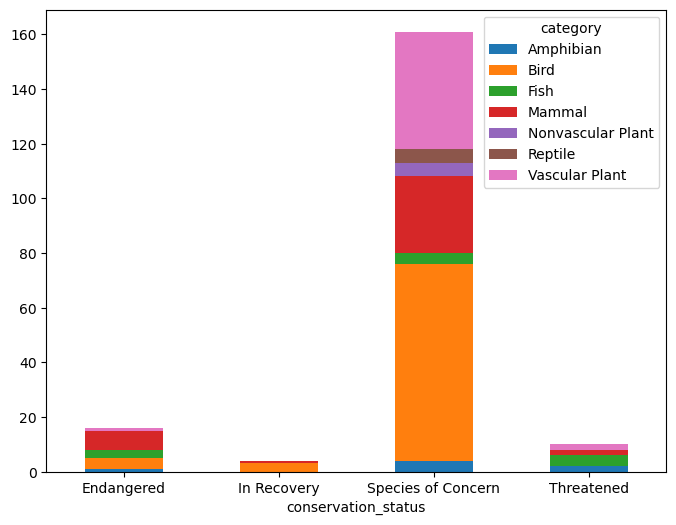

<Figure size 640x480 with 0 Axes>

In [14]:
# Stacked bar chart to see distribution of conservation status across all species
conservation_statusdf = si_df[si_df.conservation_status != "No Intervention"]\
    .groupby(["conservation_status", "category"])['scientific_name']\
    .count()\
    .unstack()
conservation_statusdf.plot(kind = 'bar', figsize=(8,6), stacked=True)
plt.xticks(rotation=0)
plt.show()
plt.clf()


### Most Endangered Categories

   category               scientific_name                                                 common_names conservation_status
8    Mammal                   Canis lupus                                                    Gray Wolf          Endangered
9    Mammal                   Canis rufus                                                     Red Wolf          Endangered
34   Mammal             Myotis grisescens                                                  Gray Myotis          Endangered
39   Mammal                Myotis sodalis                        Indiana Bat, Indiana Or Social Myotis          Endangered
72   Mammal  Glaucomys sabrinus coloratus  Carolina Northern Flying Squirrel, Northern Flying Squirrel          Endangered 

         category  count
0          Mammal      7
1            Bird      4
2            Fish      3
3  Vascular Plant      1
4       Amphibian      1


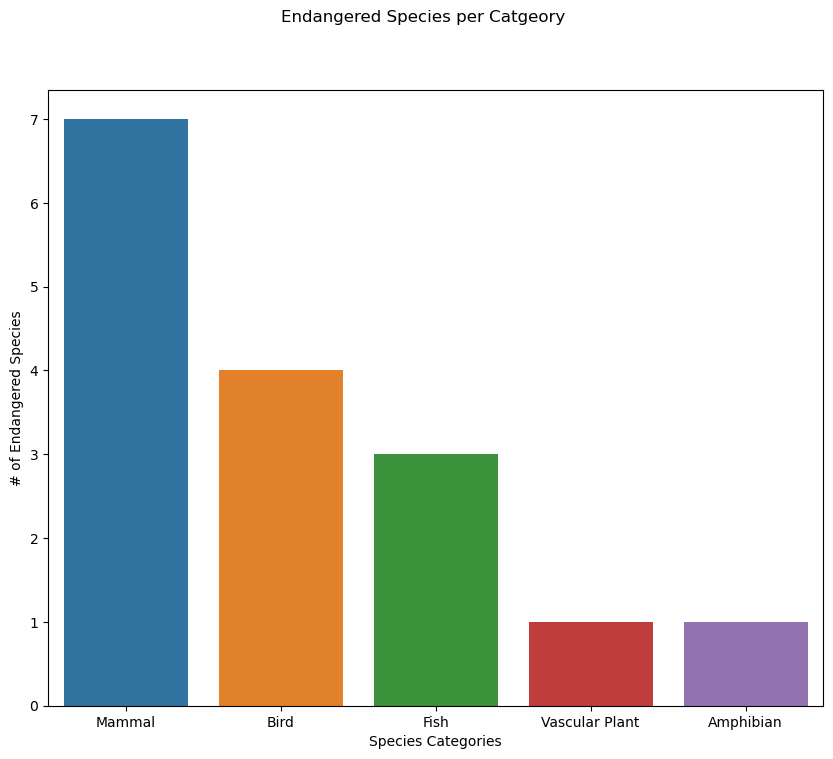

<Figure size 640x480 with 0 Axes>

In [7]:
# making a df for endangered species
endangered_df = si_df[si_df['conservation_status'] == 'Endangered']
print(endangered_df.head(), '\n')

# create df for endangered species per category
per_cat_df = endangered_df['category'].value_counts().reset_index()
print(per_cat_df.head())


# Bar plot of endangered species per category
fig = plt.figure(figsize=(10,8)).suptitle('Endangered Species per Catgeory')
sns.barplot(data=per_cat_df, x='category', y='count', hue='category')
plt.xlabel('Species Categories')
plt.ylabel('# of Endangered Species')
plt.show()
plt.clf()



## Explore observations.csv

In [8]:
print('Observations DataFrame Stats')
print(obs_df.describe(), '\n')

print(f'Rows: {obs_df.shape[0]} \nColumns: {obs_df.shape[1]} \n')

print(f'Total Number of Observations: {obs_df['observations'].sum()} \n')


missing_vals_obs = obs_df.isnull().sum()
print(f'Missing Values:\n{missing_vals_obs}, \n')

Observations DataFrame Stats
       observations
count  23296.000000
mean     142.287904
std       69.890532
min        9.000000
25%       86.000000
50%      124.000000
75%      195.000000
max      321.000000 

Rows: 23296 
Columns: 3 

Total Number of Observations: 3314739 

Missing Values:
scientific_name    0
park_name          0
observations       0
dtype: int64, 



### Observations per Park

DataFrame grouped by Park Name 

                             park_name  observations
0                  Bryce National Park        576025
1  Great Smoky Mountains National Park        431820
2            Yellowstone National Park       1443562
3               Yosemite National Park        863332


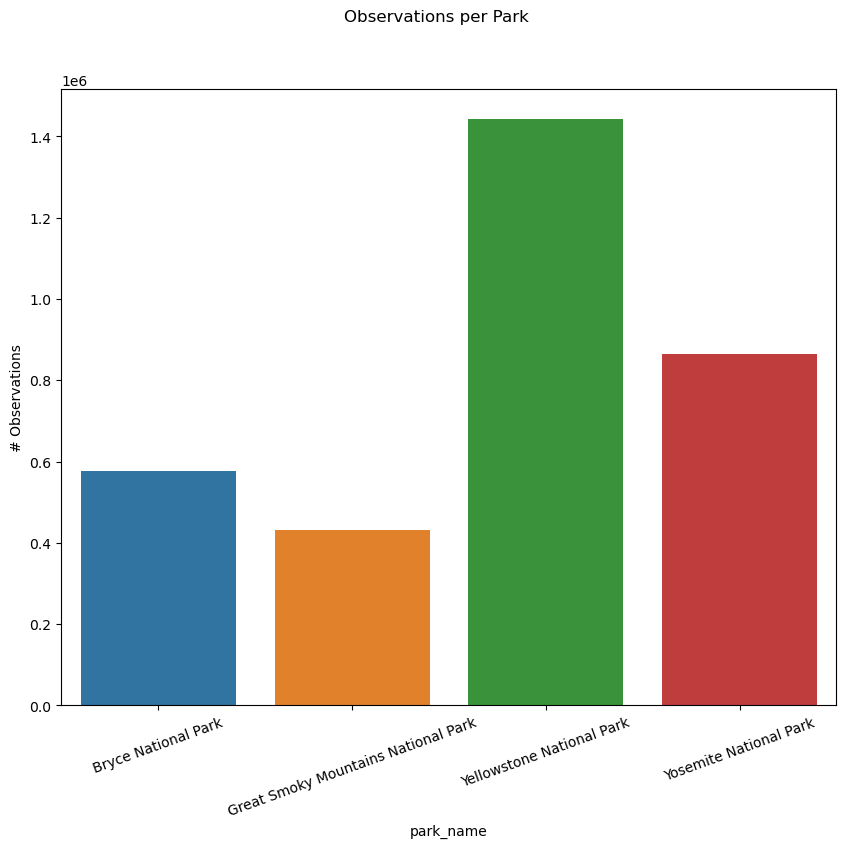

<Figure size 640x480 with 0 Axes>

In [9]:
# Number of Observations per Park in new Dataframe
park_df = obs_df.groupby('park_name').sum().reset_index()
park_df = park_df.drop(columns = ['scientific_name'])
print('DataFrame grouped by Park Name \n')
print(park_df.head())

# Barplot
plt.figure(figsize=(10,8)).suptitle('Observations per Park')
sns.barplot(data=park_df, x='park_name', y='observations', hue='park_name')
plt.ylabel('# Observations')
plt.xticks(rotation=20)
plt.show()
plt.clf()


# Conclusions